In [3]:
using Base.Threads
println("Threads available: ", Threads.nthreads())

Threads available: 8


In [4]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Revise 
using HDF5, NPZ, DataInterpolations, Interpolations, FastChebInterp
using BenchmarkTools, FFTW, FastTransforms, Dates, TOML, Plots, Plots.Measures
using QuadGK, LaTeXStrings, Tullio, StaticArrays, LoopVectorization, LinearAlgebra
using Unitful, SpecialFunctions, DifferentialEquations, Cosmology, NumericalIntegration
using CSV, DataFrames, JSON, OrderedCollections
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)
;

[ Info: Precompiling HDF5 [f67ccb44-e63f-5c2f-98bd-6dc0ccc4ba2f]
[ Info: Precompiling DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0]
Precompiling packages...
   2049.5 ms  ✓ DataInterpolations → DataInterpolationsChainRulesCoreExt
  1 dependency successfully precompiled in 3 seconds. 37 already precompiled.
[ Info: Precompiling DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd]
┌ Warning: Module DataInterpolations with build ID fafbfcfd-fd3c-ce88-6673-00e90907b32e is missing from the cache.
│ This may mean DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2022
[ Info: Skipping precompilation since __precompile__(false). Importing DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd].
Precompiling packages...
    617.7 ms  ✓ FastChebInterp
  1 dependency successfully precompiled in 1 seconds. 18 already precompiled.
[ Info: Precompili

In [5]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
include("blast_code/src/galaxy_galaxy.jl")
include("blast_code/src/shear_shear.jl")
include("blast_code/src/config.jl")
include("blast_code/src/paths.jl")
include("blast_code/src/plot_config.jl")
using .galaxy_galaxy
using .shear_shear
using .Blast
using .blast_tutorials

In [ ]:
grid_data = setup_cosmology_grid() 
grids = Blast.generate_k_grids(grid_data.kmin, grid_data.kmax, grid_data.Nk, grid_data.Nkp, grid_data.Nkpp; sorting=true) 
plot_theme = setup_plot_theme() 

sl_fast_nosort = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/runs/no_sorting_run_2026_07_20_102547/quantities/Sl/S_lkk_gg.npy")
sl_fast_sort = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/runs/yes_sorting_run_2026_07_20_104650/quantities/Sl/S_lkk_gg.npy")
#k1_test = [0.01574015850603505] h/Mpc, 
#k2_test = [0.01574015850603505] h/Mpc, 
sl_bf = [1.8471673998784959e-7, 1.8607501657430804e-7, 1.8821804766352438e-7, 1.9114851856646272e-7, 1.9114851856646272e-7, 
         1.9932621892732901e-7, 2.0455876222181502e-7, 2.1047403432535187e-7, 2.1702203747307555e-7, 2.2408287869628156e-7, 
         2.3144868100793932e-7, 2.391947376829505e-7,  2.470848732315716e-7,  2.549901613772657e-7,  2.627846909035288e-7,
         2.704709816876197e-7,  2.7752545760409443e-7, 2.8396095664282403e-7, 2.8954858770478806e-7, 2.9433389067829524e-7,
         3.0043882354439647e-7, 2.991035580482929e-7, 2.8981951620755216e-7, 2.73247534639631e-7, 2.6211856094984235e-7, 2.339277735381886e-7, 1.792294534817018e-7,  
         1.37642729352654e-7, 7.774917989993723e-8,  1.525789679681453e-8, 8.035945643486039e-10, 
         4.317756970496519e-17, 1.5513679160064766e-27, 2.3397755378059954e-42, 8.828095535136051e-60, 3.529266756774987e-80
         ]
ell_bf = [grid_data.ℓ[1], grid_data.ℓ[2], grid_data.ℓ[3], grid_data.ℓ[4], grid_data.ℓ[5], 
          grid_data.ℓ[6], grid_data.ℓ[7], grid_data.ℓ[8], grid_data.ℓ[9], grid_data.ℓ[10], 
          grid_data.ℓ[11], grid_data.ℓ[12], grid_data.ℓ[13], grid_data.ℓ[14], grid_data.ℓ[15], 
          grid_data.ℓ[16], grid_data.ℓ[17], grid_data.ℓ[18], grid_data.ℓ[19], grid_data.ℓ[20],
          grid_data.ℓ[22], grid_data.ℓ[25], grid_data.ℓ[27], grid_data.ℓ[29], grid_data.ℓ[30], grid_data.ℓ[32], grid_data.ℓ[35], 
          grid_data.ℓ[37], grid_data.ℓ[40], grid_data.ℓ[45], grid_data.ℓ[50], 
          grid_data.ℓ[60], grid_data.ℓ[70], grid_data.ℓ[80], grid_data.ℓ[90], grid_data.ℓ[100]]
;

In [60]:
xref = (grid_data.xmax - grid_data.xmin ) * 0.5
ℓ_to_k = ℓ -> ℓ ./ xref
ℓ_ticks = 1:50:200
k_ticks = ℓ_to_k.(ℓ_ticks)
k_ticklabels = [string(round(k, digits=3)) for k in k_ticks];

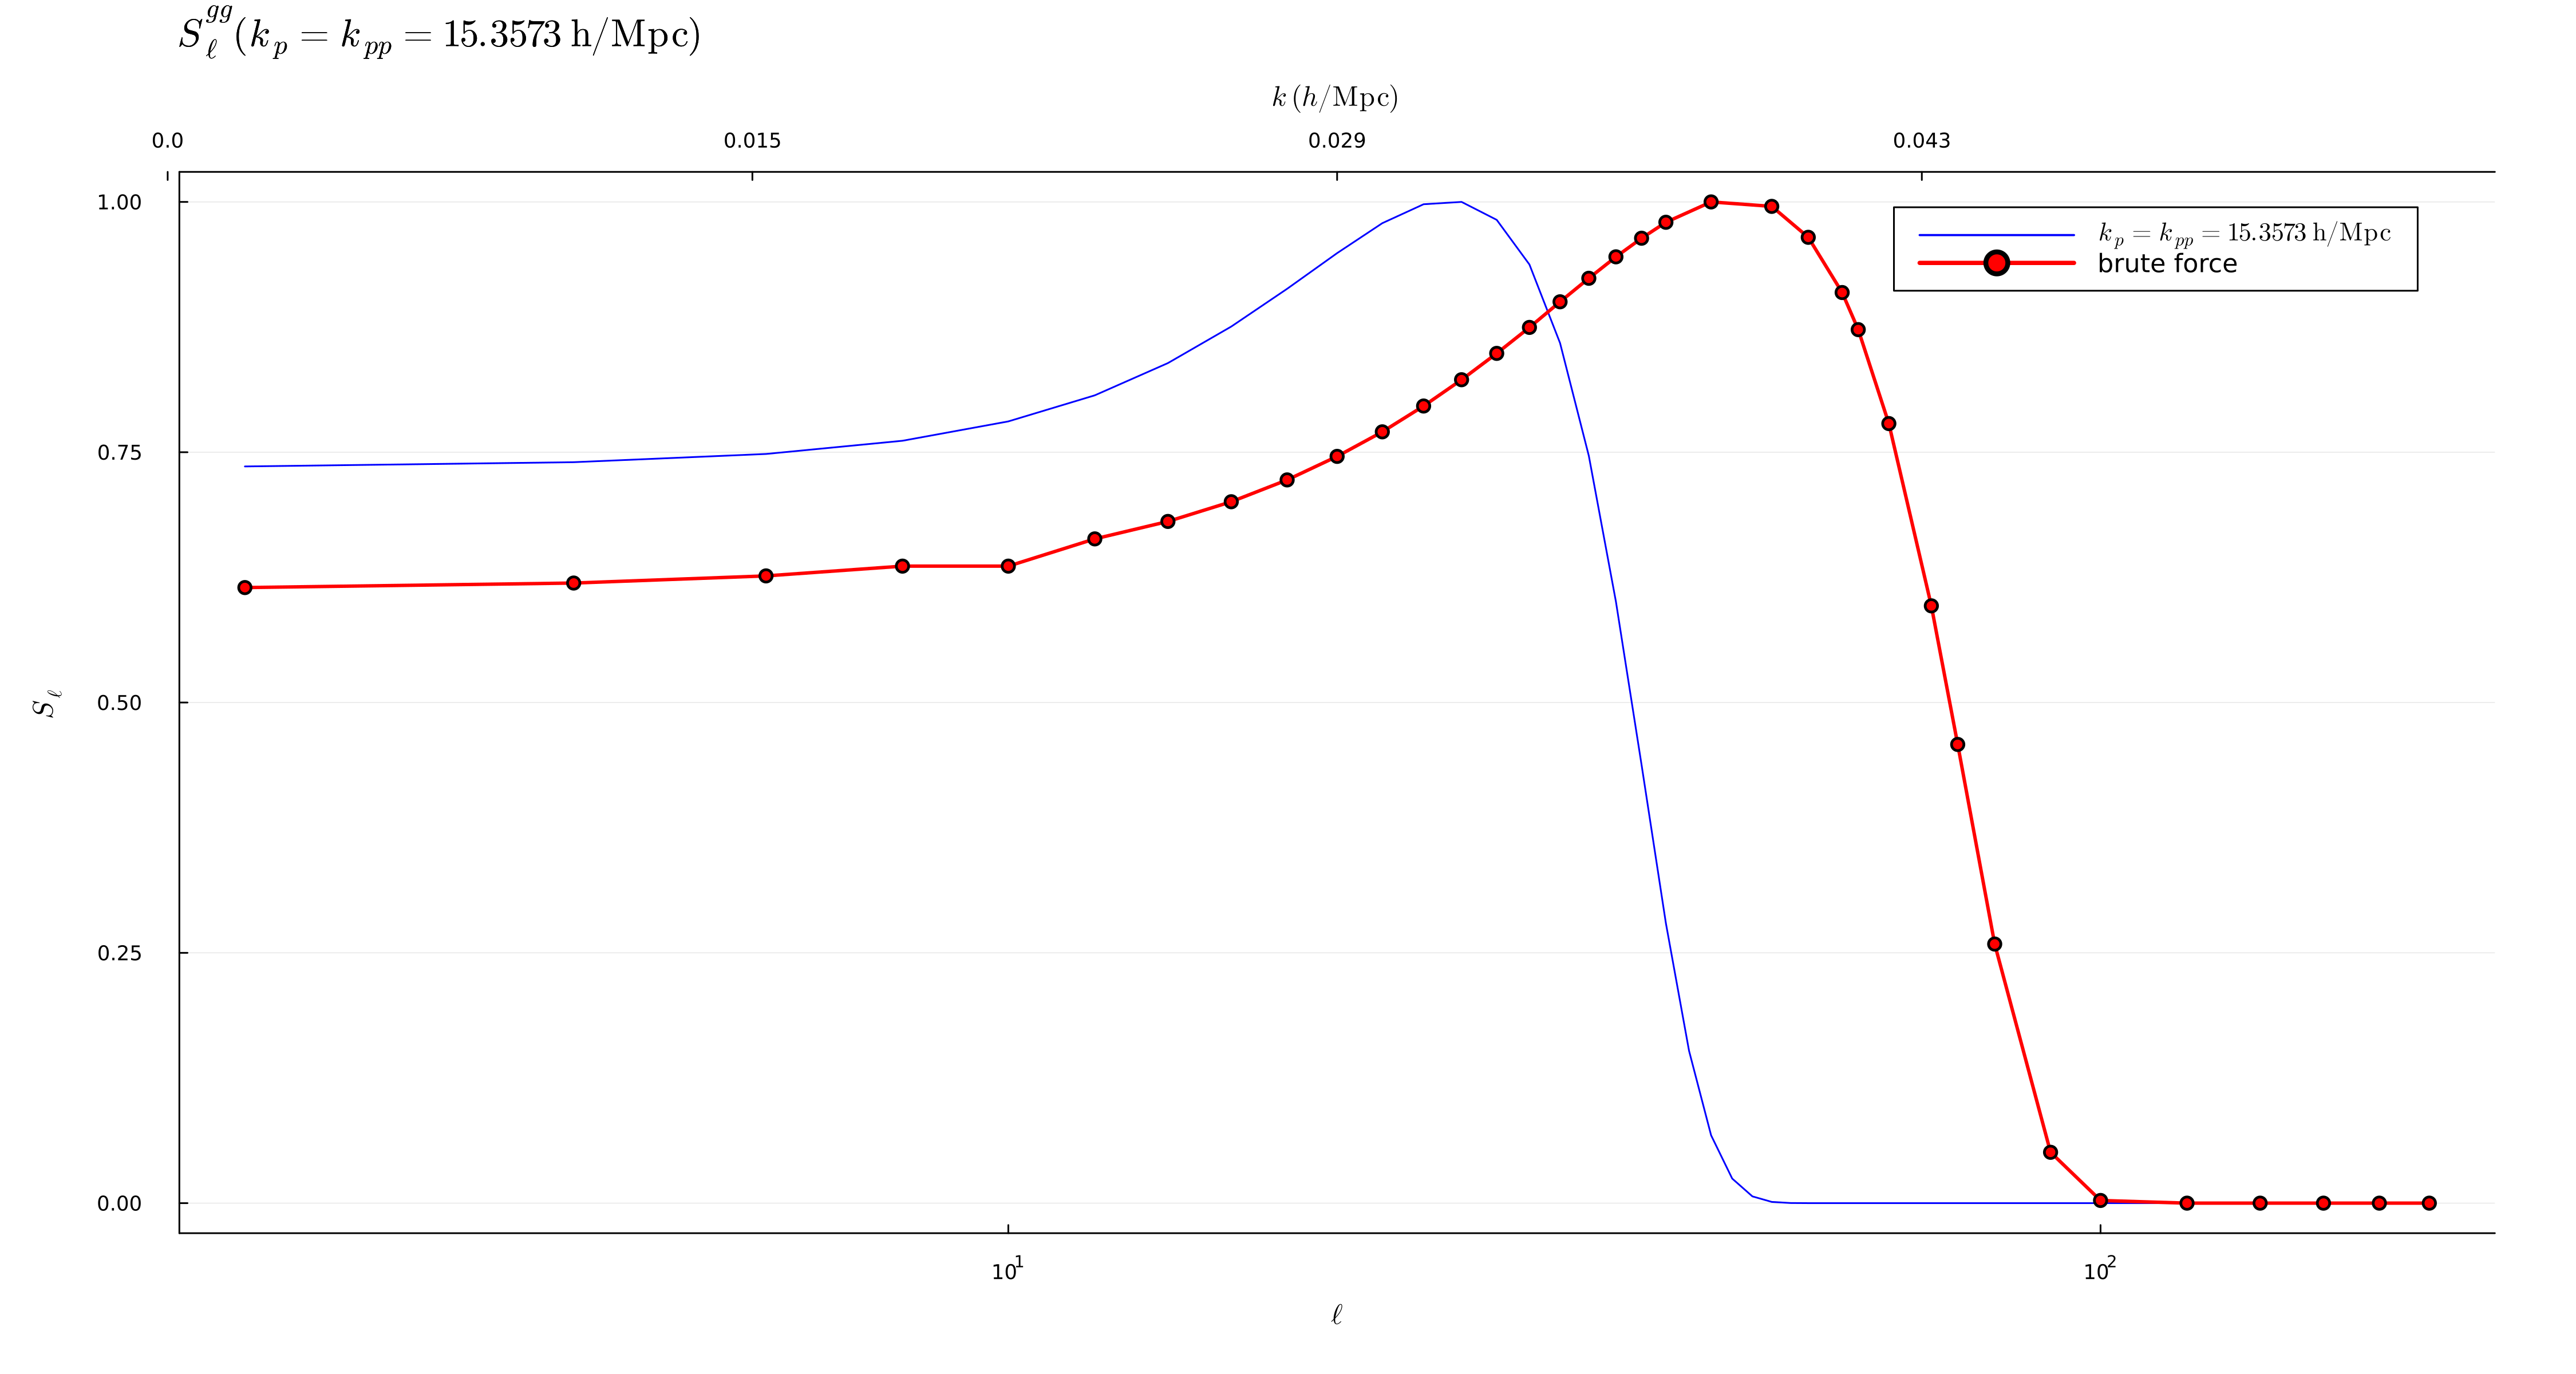

In [76]:
# i = 4
# j = i 
# k_p = grids.k_grid[i]
# k_pp = grids.kp_grid[j]
# plot(grid_data.ℓ, sl_fast_sort[i,j,:]/maximum(sl_fast_sort[i,j,:]),
#       color = :green, ls = :dash, lw = 2,
#       label = label = L"k_p = k_{pp} = %$(round(k_p, digits=5)) \; \mathrm{h/Mpc}")
#plot(grid_data.ℓ, sl_fast_nosort[grid_data.Nk-i+1,grid_data.Nk-i+1,:]/maximum(sl_fast_nosort[grid_data.Nk-i+1,grid_data.Nk-j+1,:]),
      # color = :blue, ls = :dot, lw = 2,
      # label = label = L"k_p = k_{pp} = %$(round(k_p, digits=5)) \; \mathrm{h/Mpc}")
i = 146
j = i 
k_p = grids.k_grid[i]
k_pp = grids.kp_grid[j]
plot(grid_data.ℓ, sl_fast_sort[i,j,:]/maximum(sl_fast_sort[i,j,:]),
      color = :blue,
      label = label = L"k_p = k_{pp} = %$(round(k_p, digits=4)) \; \mathrm{h/Mpc}")

plot!(ell_bf, sl_bf/maximum(sl_bf), 
      label = "brute force", 
      color = :red, 
      lw = 2, 
      ls = :solid, 
      marker = :circle, 
      markersize = 4
     )
plot!(xaxis = L"\ell",
      ylabel = L"S_\ell"
      ,xscale = :log10,
      )
plot!(twiny(),
      xaxis = L"k \; (h/\mathrm{Mpc})",
      xticks = (ℓ_ticks, k_ticklabels),
      xlims = (minimum(grid_data.ℓ), maximum(grid_data.ℓ)),
      label = ""
     )
plot!(label = "Beyond BLAST", 
      size=plot_theme.size_Cl,
      title = L"S_{\ell}^{gg} (k_p = k_{pp} = %$(round(k_p, digits=4)) \; \mathrm{h/Mpc})",
      titlefontsize = 20,
      titleposition = :left ; plot_theme.shared_style...)